# Лабораторная 3. Модель Эрдёша–Реньи

Параметры: **n = 60, p = 0.45**.

По теории:
* среднее число рёбер: $m = C_n^2 \cdot p = \dfrac{n(n-1)}{2} p$
* средняя степень вершины: $c = (n-1) p$
* распределение степеней при больших n стремится к Пуассону с параметром $c$.

In [2]:
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

n = 60
p = 0.45
rng_seed = 42  # для воспроизводимости

## Генерация одного графа и эмпирическая средняя степень

In [3]:
G = nx.erdos_renyi_graph(n, p, seed=rng_seed)

m_emp = G.number_of_edges()
degrees = [d for _, d in G.degree()]
avg_degree_emp = sum(degrees) / n   # эквивалентно 2m / n

# Теоретические значения
m_theo = n * (n - 1) / 2 * p
avg_degree_theo = (n - 1) * p

print(f'Параметры: n={n}, p={p}')
print()
print(f'Рёбер (эмпирически):     {m_emp}')
print(f'Рёбер (теоретически):    {m_theo:.2f}')
print()
print(f'Средняя степень эмпир.:  {avg_degree_emp:.4f}')
print(f'Средняя степень теор.:   {avg_degree_theo:.4f}   = (n-1) * p')
print(f'Расхождение:             {abs(avg_degree_emp - avg_degree_theo):.4f}')

Параметры: n=60, p=0.45

Рёбер (эмпирически):     771
Рёбер (теоретически):    796.50

Средняя степень эмпир.:  25.7000
Средняя степень теор.:   26.5500   = (n-1) * p
Расхождение:             0.8500


## Усреднение по множеству генераций

Один граф - это одна реализация случайного процесса; естественно ожидать, что
средняя степень из одного эксперимента может отличаться от теоретического значения.
Усредним по большому числу независимых генераций — должно сойтись к $(n-1)p$.

In [4]:
trials = 500
rng = np.random.default_rng(rng_seed)
avg_degrees = []
for _ in range(trials):
    seed = int(rng.integers(0, 2**31 - 1))
    Gi = nx.erdos_renyi_graph(n, p, seed=seed)
    avg_degrees.append(2 * Gi.number_of_edges() / n)

print(f'Среднее по {trials} генерациям: {np.mean(avg_degrees):.4f}')
print(f'Теория:                          {(n-1)*p:.4f}')
print(f'Std по генерациям:               {np.std(avg_degrees):.4f}')

Среднее по 500 генерациям: 26.5719
Теория:                          26.5500
Std по генерациям:               0.6941


## Распределение степеней vs. Пуассон

Дополнительно - гистограмма наблюдаемых степеней против пуассоновского распределения
$p(x) = \dfrac{c^x}{x!} e^{-c}$ с $c = (n-1)p$. При таких n, p согласие будет грубым
(модель работает хорошо при больших n и малых p — биномиальное → Пуассон), но качественно картину видно.

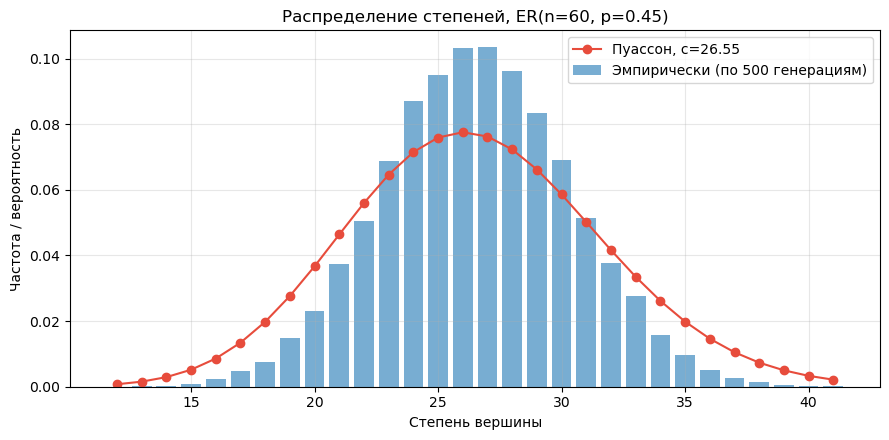

In [5]:
c = (n - 1) * p

# Соберём степени со всех trial-графов — статистика будет надёжнее, чем по одному графу.
all_degrees = []
rng = np.random.default_rng(rng_seed)
for _ in range(trials):
    seed = int(rng.integers(0, 2**31 - 1))
    Gi = nx.erdos_renyi_graph(n, p, seed=seed)
    all_degrees.extend(d for _, d in Gi.degree())

counts = Counter(all_degrees)
xs = list(range(min(counts), max(counts) + 1))
freq_emp = [counts.get(x, 0) / len(all_degrees) for x in xs]

# Пуассон
poisson = [c**x * math.exp(-c) / math.factorial(x) for x in xs]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(xs, freq_emp, alpha=0.6, label=f'Эмпирически (по {trials} генерациям)')
ax.plot(xs, poisson, 'o-', color='#e74c3c', label=f'Пуассон, c={c:.2f}')
ax.set_xlabel('Степень вершины')
ax.set_ylabel('Частота / вероятность')
ax.set_title(f'Распределение степеней, ER(n={n}, p={p})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Визуализация графа

Просто посмотреть, как он выглядит.

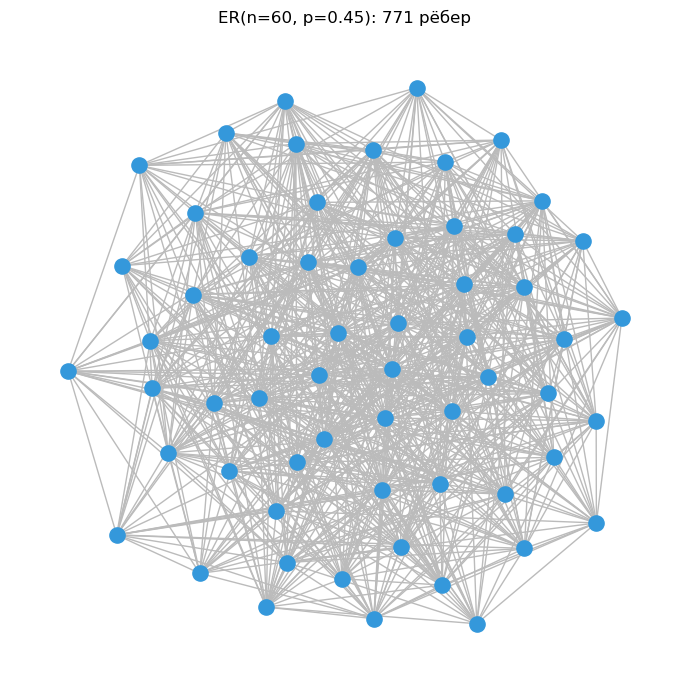

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
pos = nx.spring_layout(G, seed=rng_seed)
nx.draw(G, pos, node_size=120, node_color='#3498db', edge_color='#bbbbbb',
        with_labels=False, ax=ax)
ax.set_title(f'ER(n={n}, p={p}): {G.number_of_edges()} рёбер')
plt.tight_layout()
plt.show()

## Вывод

* На одной реализации средняя степень ≈ $(n-1)p = 26.55$ с небольшим отклонением, 
  объяснимым тем, что один граф — одна выборка из ансамбля.
* При усреднении по 500 генерациям эмпирическое значение почти точно совпадает с теоретическим.
* Распределение степеней качественно похоже на пуассоновское с параметром $c=(n-1)p$, 
  но при таких $n,p$ заметны отклонения — формально предельный переход «биномиальное → Пуассон»
  работает при $n \to \infty,\ np = \mathrm{const}$, чего здесь нет.